# Predicción de inactividad de clientes

El objetivo es estimar la probabilidad de que un cliente activo durante los 180 días anteriores a una fecha de corte no vuelva a comprar durante los 90 días siguientes.

Cada fila representa el estado de un cliente en una fecha determinada. Las variables se construyen únicamente con información disponible antes del corte y `is_inactive` indica el comportamiento observado durante la ventana posterior.

In [5]:
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn


print("Python version: ", sys.version)
print("Executable: ", sys.executable)
print("Working directory: ", Path.cwd())
print("Numpy: ", np.__version__)
print("Pandas: ", pd.__version__)
print("Scikit-Learn: ", sklearn.__version__)
print("Matplotlib: ", matplotlib.__version__)

Python version:  3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Executable:  c:\Users\hecto\Documents\Proyectos\customer_intelligence\.venv\Scripts\python.exe
Working directory:  c:\Users\hecto\Documents\Proyectos\customer_intelligence\notebooks
Numpy:  2.5.1
Pandas:  3.0.3
Scikit-Learn:  1.9.0
Matplotlib:  3.11.1


## 1. Dataset de modelado

In [6]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "inactivity_modeling.parquet"

inactivity_data = pd.read_parquet(DATA_PATH)

print("Data path: ", DATA_PATH)
print("Shape: ", inactivity_data.shape)
print("Columns: ", inactivity_data.columns)

display(inactivity_data.head())

Data path:  c:\Users\hecto\Documents\Proyectos\customer_intelligence\data\processed\inactivity_modeling.parquet
Shape:  (15063, 18)
Columns:  Index(['customer_id', 'snapshot_date', 'prediction_end_date',
       'first_purchase_date', 'last_purchase_date', 'order_count',
       'total_spend', 'total_items', 'unique_products', 'recency_days',
       'tenure_days', 'average_order_value', 'orders_last_30d',
       'orders_last_90d', 'spend_last_90d', 'items_last_90d',
       'unique_products_last_90d', 'is_inactive'],
      dtype='str')


,customer_id,snapshot_date,prediction_end_date,first_purchase_date,last_purchase_date,order_count,total_spend,total_items,unique_products,recency_days,tenure_days,average_order_value,orders_last_30d,orders_last_90d,spend_last_90d,items_last_90d,unique_products_last_90d,is_inactive
0,12346,2010-09-01,2010-11-30,2009-12-14 08:34:00,2010-06-28 13:53:00,11,372.86,70,26,65,261,33.896364,0,1,142.31,19,19,True
1,12349,2010-09-01,2010-11-30,2010-04-29 13:20:00,2010-05-18 09:57:00,2,1268.52,474,47,106,125,634.260000,0,0,0.00,0,0,False
2,12355,2010-09-01,2010-11-30,2010-05-21 11:59:00,2010-05-21 11:59:00,1,488.21,303,22,103,103,488.210000,0,0,0.00,0,0,True
3,12358,2010-09-01,2010-11-30,2009-12-08 07:59:00,2010-06-07 12:28:00,2,1697.93,590,34,86,267,848.965000,0,1,268.10,281,17,False
4,12359,2010-09-01,2010-11-30,2009-12-05 13:32:00,2010-06-22 10:24:00,5,1918.03,661,80,71,270,383.606000,0,1,489.80,100,20,False


## 2. Validación inicial y distribución temporal

Antes de entrenar el modelo se revisa la integridad del dataset y la proporción de clientes inactivos en cada snapshot.

In [7]:
duplicate_pairs = inactivity_data.duplicated(["customer_id", "snapshot_date"]).sum()

missing_values = inactivity_data.isna().sum().sum()

invalid_windows = inactivity_data["prediction_end_date"].le(inactivity_data["snapshot_date"]).sum()

snapshot_summary = inactivity_data.groupby("snapshot_date").agg(
    observations=("customer_id", "size"),
    unique_customers=("customer_id", "nunique"),
    inactive_customers=("is_inactive", "sum"),
    inactivity_rate=("is_inactive", "mean")
)

snapshot_summary["inactivity_rate_pct"] = snapshot_summary["inactivity_rate"] * 100

snapshot_summary = snapshot_summary.drop(columns="inactivity_rate")

print("Duplicate customer-snapshot pairs: ", duplicate_pairs)
print("Missing values: ", missing_values)
print("Invalid prediction windows: ", invalid_windows)

display(snapshot_summary.round(2))

Duplicate customer-snapshot pairs:  0
Missing values:  0
Invalid prediction windows:  0


,observations,unique_customers,inactive_customers,inactivity_rate_pct
snapshot_date,,,,
2010-09-01,2824,2824,1073,38.00
2010-12-01,3466,3466,2151,62.06
2011-03-01,3337,3337,1924,57.66
2011-06-01,2655,2655,1326,49.94
2011-09-10,2781,2781,1062,38.19


## 3. Separación temporal

El modelo se entrena con los tres primeros snapshots, se selecciona utilizando el cuarto y se evalúa una sola vez sobre el último periodo.

Esta separación reproduce un escenario real: utilizar información histórica para estimar el riesgo de clientes en una fecha posterior.

In [8]:
TARGET = "is_inactive"

TRAIN_SNAPSHOTS = pd.to_datetime(["2010-09-01", "2010-12-01", "2011-03-01"])

VALIDATION_SNAPSHOT = pd.Timestamp("2011-06-01")

TEST_SNAPSHOT = pd.Timestamp("2011-09-10")

train_data = inactivity_data.loc[inactivity_data["snapshot_date"].isin(TRAIN_SNAPSHOTS)].copy()

validation_data = inactivity_data.loc[inactivity_data["snapshot_date"] == VALIDATION_SNAPSHOT].copy()

test_data = inactivity_data.loc[inactivity_data["snapshot_date"] == TEST_SNAPSHOT].copy()

if train_data["prediction_end_date"].max() >= VALIDATION_SNAPSHOT:
    raise ValueError("Training labels must end before the validation snapshot")

if validation_data["prediction_end_date"].max() >= TEST_SNAPSHOT:
    raise ValueError("Validation labels must end before the test snapshot")

split_summary = pd.DataFrame(
    {
        "observations": [len(train_data), len(validation_data), len(test_data)],
        "unique_customers": [
            train_data["customer_id"].nunique(),
            validation_data["customer_id"].nunique(),
            test_data["customer_id"].nunique()
        ],
        "inactivity_rate_pct": [
            train_data[TARGET].mean() * 100,
            validation_data[TARGET].mean() * 100,
            test_data[TARGET].mean() * 100
        ]
    },
    index=["train", "validation", "test"]
)

display(split_summary.round(2))

,observations,unique_customers,inactivity_rate_pct
train,9627,4243,53.47
validation,2655,2655,49.94
test,2781,2781,38.19


## 4. Selección y análisis de variables

Se utilizan métricas acumuladas y de actividad reciente. Los identificadores y las fechas absolutas quedan fuera del entrenamiento para evitar que el modelo aprenda relaciones específicas de clientes o periodos.

In [9]:
CANDIDATE_FEATURES = [
    "order_count",
    "total_spend",
    "total_items",
    "unique_products",
    "recency_days",
    "tenure_days",
    "average_order_value",
    "orders_last_30d",
    "orders_last_90d",
    "spend_last_90d",
    "items_last_90d",
    "unique_products_last_90d"
]

feature_summary = pd.DataFrame(
    {
        "dtype": train_data[CANDIDATE_FEATURES].dtypes.astype(str),
        "missing": train_data[CANDIDATE_FEATURES].isna().sum(),
        "minimum": train_data[CANDIDATE_FEATURES].min(),
        "median": train_data[CANDIDATE_FEATURES].median(),
        "mean": train_data[CANDIDATE_FEATURES].mean(),
        "p95": train_data[CANDIDATE_FEATURES].quantile(0.95),
        "maximum": train_data[CANDIDATE_FEATURES].max(),
        "skewness": train_data[CANDIDATE_FEATURES].skew()
    }
)

display(feature_summary.round(2))

,dtype,missing,minimum,median,mean,p95,maximum,skewness
order_count,int64,0,1.00,3.00,4.96,15.00,212.00,9.35
total_spend,float64,0,3.75,848.31,2261.56,6738.75,357121.43,22.15
total_items,int64,0,1.00,467.00,1394.00,3826.90,218094.00,18.95
unique_products,int64,0,1.00,44.00,70.14,213.00,1780.00,5.77
recency_days,int64,0,1.00,54.00,65.91,160.00,180.00,0.51
tenure_days,int64,0,1.00,213.00,218.54,446.70,455.00,0.16
average_order_value,float64,0,3.75,292.11,378.24,924.53,11880.84,11.40
orders_last_30d,int64,0,0.00,0.00,0.51,2.00,28.00,7.11
orders_last_90d,int64,0,0.00,1.00,1.43,4.00,78.00,9.65
spend_last_90d,float64,0,0.00,240.60,640.23,2077.57,113192.92,21.78


### 4.1 Correlación entre variables

Se utiliza correlación de Spearman porque varias variables presentan distribuciones asimétricas y valores extremos.

In [10]:
feature_correlations = train_data[CANDIDATE_FEATURES].corr(method="spearman")

display(feature_correlations.round(2))

,order_count,total_spend,total_items,unique_products,recency_days,tenure_days,average_order_value,orders_last_30d,orders_last_90d,spend_last_90d,items_last_90d,unique_products_last_90d
order_count,1.00,0.83,0.77,0.66,-0.38,0.74,0.16,0.34,0.53,0.47,0.45,0.39
total_spend,0.83,1.00,0.94,0.73,-0.33,0.61,0.66,0.30,0.45,0.57,0.53,0.42
total_items,0.77,0.94,1.00,0.71,-0.32,0.57,0.62,0.29,0.43,0.54,0.56,0.41
unique_products,0.66,0.73,0.71,1.00,-0.28,0.49,0.40,0.25,0.36,0.42,0.41,0.54
recency_days,-0.38,-0.33,-0.32,-0.28,1.00,0.02,-0.09,-0.82,-0.82,-0.78,-0.77,-0.76
tenure_days,0.74,0.61,0.57,0.49,0.02,1.00,0.13,0.02,0.07,0.08,0.06,0.02
average_order_value,0.16,0.66,0.62,0.40,-0.09,0.13,1.00,0.08,0.11,0.38,0.35,0.23
orders_last_30d,0.34,0.30,0.29,0.25,-0.82,0.02,0.08,1.00,0.64,0.58,0.57,0.55
orders_last_90d,0.53,0.45,0.43,0.36,-0.82,0.07,0.11,0.64,1.00,0.90,0.88,0.84
spend_last_90d,0.47,0.57,0.54,0.42,-0.78,0.08,0.38,0.58,0.90,1.00,0.97,0.89


### 4.2 Perfil de la variable objetivo

Se comparan las medianas de cada variable entre clientes que volvieron a comprar y clientes que quedaron inactivos.

In [11]:
target_profiles = train_data.groupby(TARGET)[CANDIDATE_FEATURES].median().T

target_profiles = target_profiles.rename(
    columns={
        False: "active_median",
        True: "inactive_median"
    }
)

target_profiles["absolute_difference"] = target_profiles["inactive_median"] - target_profiles["active_median"]

display(target_profiles.round(2))

is_inactive,active_median,inactive_median,absolute_difference
order_count,4.00,2.00,-2.00
total_spend,1425.19,561.42,-863.77
total_items,798.00,304.00,-494.00
unique_products,62.00,32.00,-30.00
recency_days,36.00,76.00,40.00
tenure_days,261.00,168.00,-93.00
average_order_value,314.41,267.50,-46.91
orders_last_30d,0.00,0.00,0.00
orders_last_90d,1.00,1.00,0.00
spend_last_90d,398.55,131.80,-266.75


### 4.3 Variables seleccionadas

Se eliminan `total_items` e `items_last_90d` por su alta correlación con las variables de gasto. Las fechas, identificadores y la variable objetivo tampoco participan en el entrenamiento.

Las métricas excluidas se mantienen disponibles para el análisis descriptivo.

In [12]:
MODEL_FEATURES = [
    "recency_days",
    "tenure_days",
    "order_count",
    "total_spend",
    "unique_products",
    "average_order_value",
    "orders_last_30d",
    "orders_last_90d",
    "spend_last_90d",
    "unique_products_last_90d"
]

MODEL_LOG_FEATURES = [
    "order_count",
    "total_spend",
    "unique_products",
    "average_order_value",
    "orders_last_30d",
    "orders_last_90d",
    "spend_last_90d",
    "unique_products_last_90d"
]

MODEL_SCALE_ONLY_FEATURES = ["recency_days", "tenure_days"]

PROFILING_ONLY_FEATURES = ["total_items", "items_last_90d"]

X_train = train_data[MODEL_FEATURES].copy()
y_train = train_data[TARGET].astype("int64")

X_validation = validation_data[MODEL_FEATURES].copy()
y_validation = validation_data[TARGET].astype("int64")

X_test = test_data[MODEL_FEATURES].copy()
y_test = test_data[TARGET].astype("int64")

print("Model features: ", MODEL_FEATURES)
print("Log transformed features: ", MODEL_LOG_FEATURES)
print("Scale only features: ", MODEL_SCALE_ONLY_FEATURES)
print("Profiling only features: ", PROFILING_ONLY_FEATURES)
print()
print("Train shape: ", X_train.shape)
print("Validation shape: ", X_validation.shape)
print("Test shape: ", X_test.shape)

Model features:  ['recency_days', 'tenure_days', 'order_count', 'total_spend', 'unique_products', 'average_order_value', 'orders_last_30d', 'orders_last_90d', 'spend_last_90d', 'unique_products_last_90d']
Log transformed features:  ['order_count', 'total_spend', 'unique_products', 'average_order_value', 'orders_last_30d', 'orders_last_90d', 'spend_last_90d', 'unique_products_last_90d']
Scale only features:  ['recency_days', 'tenure_days']
Profiling only features:  ['total_items', 'items_last_90d']

Train shape:  (9627, 10)
Validation shape:  (2655, 10)
Test shape:  (2781, 10)


## 5. Preprocesamiento

Las variables asimétricas reciben una transformación `log1p`. Después se estandarizan todas las variables para que la regresión logística trabaje sobre escalas comparables.

El preprocesamiento se ajusta únicamente con entrenamiento.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler


log_pipeline = Pipeline(steps=[("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), ("scaler", StandardScaler())])

linear_preprocessor = ColumnTransformer(transformers=[("log_features", log_pipeline, MODEL_LOG_FEATURES), ("scale_only", StandardScaler(), MODEL_SCALE_ONLY_FEATURES)], remainder="drop", verbose_feature_names_out=False)

preprocessed_train_array = linear_preprocessor.fit_transform(X_train)

preprocessed_train = pd.DataFrame(preprocessed_train_array, columns=linear_preprocessor.get_feature_names_out(), index=X_train.index)

preprocessed_train = preprocessed_train[MODEL_FEATURES]

preprocessing_summary = pd.DataFrame(
    {
        "mean": preprocessed_train.mean(),
        "standard_deviation": preprocessed_train.std(),
        "minimum": preprocessed_train.min(),
        "maximum": preprocessed_train.max()
    }
)

display(preprocessing_summary.round(2))

,mean,standard_deviation,minimum,maximum
recency_days,0.0,1.0,-1.28,2.24
tenure_days,-0.0,1.0,-1.71,1.86
order_count,0.0,1.0,-1.09,5.57
total_spend,-0.0,1.0,-4.15,4.80
unique_products,-0.0,1.0,-2.72,3.39
average_order_value,-0.0,1.0,-5.70,5.17
orders_last_30d,0.0,1.0,-0.66,6.99
orders_last_90d,0.0,1.0,-1.14,6.22
spend_last_90d,0.0,1.0,-1.37,2.50
unique_products_last_90d,-0.0,1.0,-1.26,2.79


## 6. Baseline y regresión logística

Se utiliza `DummyClassifier` como referencia mínima. Luego se entrena una regresión logística regularizada con el preprocesamiento definido anteriormente.

Los modelos se comparan inicialmente sobre validación utilizando un umbral de 0.50.

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, f1_score, precision_score, recall_score, roc_auc_score


def evaluate_classifier(model_name, model, features, target, threshold=0.50):
    probabilities = model.predict_proba(features)[:, 1]

    predictions = probabilities >= threshold

    return {
        "model": model_name,
        "accuracy": accuracy_score(target, predictions),
        "precision": precision_score(target, predictions, zero_division=0),
        "recall": recall_score(target, predictions, zero_division=0),
        "f1_score": f1_score(target, predictions, zero_division=0),
        "roc_auc": roc_auc_score(target, probabilities),
        "average_precision": average_precision_score(target, probabilities),
        "brier_score": brier_score_loss(target, probabilities)
    }


dummy_model = DummyClassifier(strategy="prior")

dummy_model.fit(X_train, y_train)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("classifier", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

validation_evaluation = pd.DataFrame(
    [
        evaluate_classifier("Dummy baseline", dummy_model, X_validation, y_validation),
        evaluate_classifier("Logistic regression", logistic_model, X_validation, y_validation)
    ]
).set_index("model")

display(validation_evaluation.round(3))

,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score
model,,,,,,,
Dummy baseline,0.499,0.499,1.000,0.666,0.500,0.499,0.251
Logistic regression,0.707,0.696,0.736,0.715,0.779,0.751,0.191


### 6.1 Random Forest

Se incorpora Random Forest como alternativa no lineal. Se limita el tamaño mínimo de las hojas para reducir el sobreajuste sobre clientes individuales.

In [15]:
from sklearn.ensemble import RandomForestClassifier


random_forest_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

model_evaluation = pd.DataFrame(
    [
        evaluate_classifier("Dummy baseline", dummy_model, X_validation, y_validation),
        evaluate_classifier("Logistic regression", logistic_model, X_validation, y_validation),
        evaluate_classifier("Random forest", random_forest_model, X_validation, y_validation)
    ]
).set_index("model")

display(model_evaluation.round(3))

,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score
model,,,,,,,
Dummy baseline,0.499,0.499,1.000,0.666,0.500,0.499,0.251
Logistic regression,0.707,0.696,0.736,0.715,0.779,0.751,0.191
Random forest,0.701,0.683,0.749,0.714,0.772,0.738,0.193


### 6.2 Validación temporal progresiva

Se realizan tres evaluaciones consecutivas. En cada una, el modelo utiliza únicamente snapshots anteriores al periodo validado.

El snapshot final de septiembre permanece fuera de este proceso.

In [16]:
from sklearn.base import clone


ROLLING_VALIDATION_SNAPSHOTS = pd.to_datetime(["2010-12-01", "2011-03-01", "2011-06-01"])

model_prototypes = {
    "Dummy baseline": dummy_model,
    "Logistic regression": logistic_model,
    "Random forest": random_forest_model
}

rolling_evaluation_rows = []

for validation_snapshot in ROLLING_VALIDATION_SNAPSHOTS:
    rolling_train = inactivity_data.loc[inactivity_data["snapshot_date"] < validation_snapshot].copy()

    rolling_validation = inactivity_data.loc[inactivity_data["snapshot_date"] == validation_snapshot].copy()

    X_rolling_train = rolling_train[MODEL_FEATURES]
    y_rolling_train = rolling_train[TARGET].astype("int64")

    X_rolling_validation = rolling_validation[MODEL_FEATURES]
    y_rolling_validation = rolling_validation[TARGET].astype("int64")

    for model_name, model_prototype in model_prototypes.items():
        comparison_model = clone(model_prototype)

        comparison_model.fit(X_rolling_train, y_rolling_train)

        evaluation = evaluate_classifier(model_name, comparison_model, X_rolling_validation, y_rolling_validation)

        evaluation["validation_snapshot"] = validation_snapshot

        rolling_evaluation_rows.append(evaluation)

rolling_evaluation = pd.DataFrame(rolling_evaluation_rows)

rolling_summary = rolling_evaluation.groupby("model").agg(
    mean_f1_score=("f1_score", "mean"),
    mean_roc_auc=("roc_auc", "mean"),
    mean_average_precision=("average_precision", "mean"),
    mean_brier_score=("brier_score", "mean")
)

display(rolling_evaluation.round(3))

display(rolling_summary.sort_values("mean_roc_auc", ascending=False).round(3))

C:\Users\hecto\AppData\Local\Temp\ipykernel_24176\2677188911.py:45: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(rolling_evaluation.round(3))


,model,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score,validation_snapshot
0,Dummy baseline,0.379,0.000,0.000,0.000,0.500,0.621,0.293,2010-12-01
1,Logistic regression,0.533,0.861,0.296,0.441,0.764,0.817,0.279,2010-12-01
2,Random forest,0.535,0.846,0.306,0.449,0.754,0.802,0.280,2010-12-01
3,Dummy baseline,0.577,0.577,1.000,0.731,0.500,0.577,0.248,2011-03-01
4,Logistic regression,0.717,0.756,0.752,0.754,0.778,0.799,0.191,2011-03-01
5,Random forest,0.701,0.737,0.748,0.743,0.750,0.771,0.199,2011-03-01
6,Dummy baseline,0.499,0.499,1.000,0.666,0.500,0.499,0.251,2011-06-01
7,Logistic regression,0.707,0.696,0.736,0.715,0.779,0.751,0.191,2011-06-01
8,Random forest,0.701,0.683,0.749,0.714,0.772,0.738,0.193,2011-06-01


,mean_f1_score,mean_roc_auc,mean_average_precision,mean_brier_score
model,,,,
Logistic regression,0.637,0.774,0.789,0.221
Random forest,0.636,0.759,0.770,0.224
Dummy baseline,0.466,0.500,0.566,0.264


## 7. Selección del umbral de alerta

El umbral se elige sobre validación y permanece fijo para la evaluación final. Se prioriza detectar al menos el 80% de los clientes inactivos y reducir los falsos positivos dentro de esa restricción.

In [17]:
validation_probabilities = logistic_model.predict_proba(X_validation)[:, 1]

threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.05):
    predictions = validation_probabilities >= threshold

    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_validation, predictions, zero_division=0),
            "recall": recall_score(y_validation, predictions, zero_division=0),
            "f1_score": f1_score(y_validation, predictions, zero_division=0),
            "alert_rate_pct": predictions.mean() * 100
        }
    )

threshold_evaluation = pd.DataFrame(threshold_rows)

eligible_thresholds = threshold_evaluation.loc[threshold_evaluation["recall"] >= 0.80]

selected_threshold = eligible_thresholds.sort_values(["precision", "threshold"], ascending=[False, False]).iloc[0]["threshold"]

print("Selected threshold: ", f"{selected_threshold:.2f}")

display(threshold_evaluation.round(3))

Selected threshold:  0.45


,threshold,precision,recall,f1_score,alert_rate_pct
0,0.20,0.563,0.979,0.715,86.817
1,0.25,0.581,0.967,0.726,83.126
2,0.30,0.603,0.945,0.736,78.305
3,0.35,0.623,0.904,0.738,72.505
4,0.40,0.639,0.855,0.731,66.893
5,0.45,0.667,0.805,0.730,60.226
6,0.50,0.696,0.736,0.715,52.844
7,0.55,0.728,0.659,0.692,45.198
8,0.60,0.747,0.572,0.648,38.230
9,0.65,0.764,0.459,0.573,29.981


In [18]:
test_probabilities = logistic_model.predict_proba(X_test)[:, 1]

test_predictions = test_probabilities >= selected_threshold

final_evaluation = pd.DataFrame(
    [
        evaluate_classifier(
            "Validation",
            logistic_model,
            X_validation,
            y_validation,
            threshold=selected_threshold
        ),
        evaluate_classifier(
            "Test",
            logistic_model,
            X_test,
            y_test,
            threshold=selected_threshold
        )
    ]
).set_index("model")

final_evaluation["alert_rate_pct"] = [
    (validation_probabilities >= selected_threshold).mean() * 100,
    test_predictions.mean() * 100
]

print("Selected threshold: ", f"{selected_threshold:.2f}")

display(final_evaluation.round(3))

Selected threshold:  0.45


,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score,alert_rate_pct
model,,,,,,,,
Validation,0.702,0.667,0.805,0.730,0.779,0.751,0.191,60.226
Test,0.646,0.523,0.841,0.645,0.759,0.638,0.206,61.453


In [19]:
from sklearn.metrics import confusion_matrix


test_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test, test_predictions),
    index=["Actual active", "Actual inactive"],
    columns=["Predicted active", "Predicted inactive"]
)

display(test_confusion_matrix)

,Predicted active,Predicted inactive
Actual active,903,816
Actual inactive,169,893


## 8. Segmentación del riesgo

Las probabilidades se agrupan en niveles de riesgo para facilitar su uso comercial. El umbral de alerta comienza en 0.45, mientras que los casos con una probabilidad igual o superior a 0.65 reciben la mayor prioridad.

In [20]:
RISK_BINS = [-np.inf, 0.30, 0.45, 0.65, np.inf]

RISK_LABELS = ["Bajo", "Moderado", "Alto", "Crítico"]

test_risk_data = pd.DataFrame(
    {
        "customer_id": test_data["customer_id"].values,
        "inactivity_probability": test_probabilities,
        "is_inactive": y_test.values
    }
)

test_risk_data["risk_level"] = pd.cut(
    test_risk_data["inactivity_probability"],
    bins=RISK_BINS,
    labels=RISK_LABELS,
    right=False
)

test_risk_summary = test_risk_data.groupby("risk_level", observed=True).agg(
    customers=("customer_id", "size"),
    inactive_customers=("is_inactive", "sum"),
    average_predicted_risk=("inactivity_probability", "mean"),
    actual_inactivity_rate=("is_inactive", "mean")
)

test_risk_summary["customer_share_pct"] = test_risk_summary["customers"] / len(test_risk_data) * 100

test_risk_summary["inactive_capture_pct"] = test_risk_summary["inactive_customers"] / y_test.sum() * 100

test_risk_summary["average_predicted_risk_pct"] = test_risk_summary["average_predicted_risk"] * 100

test_risk_summary["actual_inactivity_rate_pct"] = test_risk_summary["actual_inactivity_rate"] * 100

test_risk_summary = test_risk_summary[
    [
        "customers",
        "customer_share_pct",
        "inactive_customers",
        "inactive_capture_pct",
        "average_predicted_risk_pct",
        "actual_inactivity_rate_pct"
    ]
]

display(test_risk_summary.round(2))

,customers,customer_share_pct,inactive_customers,inactive_capture_pct,average_predicted_risk_pct,actual_inactivity_rate_pct
risk_level,,,,,,
Bajo,596,21.43,56,5.27,16.56,9.40
Moderado,476,17.12,113,10.64,37.71,23.74
Alto,842,30.28,353,33.24,55.46,41.92
Crítico,867,31.18,540,50.85,74.02,62.28


## 9. Interpretación del modelo

Los niveles de riesgo separan correctamente los perfiles de clientes: la inactividad observada aumenta de manera progresiva desde el nivel bajo hasta el crítico. Los niveles alto y crítico reúnen el 84.1% de los clientes inactivos.

Las probabilidades presentan cierta sobreestimación en el período de prueba, posiblemente relacionada con el cambio temporal de la tasa de inactividad. Por este motivo, el resultado se utiliza principalmente para priorizar clientes y la calibración deberá revisarse con datos más recientes.

In [21]:
fitted_preprocessor = logistic_model.steps[0][1]

logistic_classifier = logistic_model.steps[-1][1]

coefficient_summary = pd.DataFrame(
    {
        "feature": fitted_preprocessor.get_feature_names_out(),
        "coefficient": logistic_classifier.coef_[0]
    }
)

coefficient_summary["odds_ratio"] = np.exp(coefficient_summary["coefficient"])

coefficient_summary["absolute_coefficient"] = coefficient_summary["coefficient"].abs()

coefficient_summary["effect"] = np.where(
    coefficient_summary["coefficient"] > 0,
    "Aumenta el riesgo",
    "Reduce el riesgo"
)

coefficient_summary = coefficient_summary.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(coefficient_summary.round(3))

,feature,coefficient,odds_ratio,absolute_coefficient,effect
0,order_count,-1.051,0.350,1.051,Reduce el riesgo
5,orders_last_90d,-0.323,0.724,0.323,Reduce el riesgo
9,tenure_days,0.264,1.303,0.264,Aumenta el riesgo
6,spend_last_90d,0.217,1.243,0.217,Aumenta el riesgo
3,average_order_value,-0.212,0.809,0.212,Reduce el riesgo
7,unique_products_last_90d,-0.143,0.867,0.143,Reduce el riesgo
4,orders_last_30d,0.045,1.046,0.045,Aumenta el riesgo
1,total_spend,0.041,1.042,0.041,Aumenta el riesgo
8,recency_days,0.034,1.035,0.034,Aumenta el riesgo
2,unique_products,-0.003,0.997,0.003,Reduce el riesgo


## 10. Comparación con un modelo basado únicamente en recencia

La recencia suele ser una de las señales más importantes de inactividad. Para comprobar si el modelo completo aporta información adicional, se lo compara con una regresión logística que utiliza solamente los días transcurridos desde la última compra.

In [22]:
X_train_recency = train_data[["recency_days"]].copy()

X_validation_recency = validation_data[["recency_days"]].copy()

X_test_recency = test_data[["recency_days"]].copy()

recency_only_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

recency_only_model.fit(X_train_recency, y_train)

recency_validation_probabilities = recency_only_model.predict_proba(X_validation_recency)[:, 1]

recency_threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.05):
    predictions = recency_validation_probabilities >= threshold

    recency_threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_validation, predictions, zero_division=0),
            "recall": recall_score(y_validation, predictions, zero_division=0)
        }
    )

recency_threshold_evaluation = pd.DataFrame(recency_threshold_rows)

eligible_recency_thresholds = recency_threshold_evaluation.loc[recency_threshold_evaluation["recall"] >= 0.80]

selected_recency_threshold = eligible_recency_thresholds.sort_values(
    ["precision", "threshold"],
    ascending=[False, False]
).iloc[0]["threshold"]

full_model_test_results = evaluate_classifier(
    "Full logistic regression",
    logistic_model,
    X_test,
    y_test,
    threshold=selected_threshold
)

recency_model_test_results = evaluate_classifier(
    "Recency-only logistic regression",
    recency_only_model,
    X_test_recency,
    y_test,
    threshold=selected_recency_threshold
)

baseline_comparison = pd.DataFrame(
    [
        full_model_test_results,
        recency_model_test_results
    ]
).set_index("model")

baseline_comparison["selected_threshold"] = [
    selected_threshold,
    selected_recency_threshold
]

baseline_comparison["alert_rate_pct"] = [
    test_predictions.mean() * 100,
    (recency_only_model.predict_proba(X_test_recency)[:, 1] >= selected_recency_threshold).mean() * 100
]

display(baseline_comparison.round(3))

,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score,selected_threshold,alert_rate_pct
model,,,,,,,,,
Full logistic regression,0.646,0.523,0.841,0.645,0.759,0.638,0.206,0.45,61.453
Recency-only logistic regression,0.469,0.412,0.911,0.567,0.655,0.527,0.243,0.40,84.430


## 11. Lift y capacidad de priorización

El análisis de lift permite medir cuántos clientes inactivos pueden encontrarse al revisar solamente una proporción de la cartera ordenada por riesgo. Esta evaluación representa un escenario en el que el equipo comercial tiene capacidad limitada para realizar acciones de retención.

In [23]:
ranked_test_customers = test_risk_data.sort_values(
    "inactivity_probability",
    ascending=False
).reset_index(drop=True)

overall_inactivity_rate = ranked_test_customers["is_inactive"].mean()

lift_rows = []

for top_customer_pct in [10, 20, 30]:
    customer_limit = int(np.ceil(len(ranked_test_customers) * top_customer_pct / 100))

    selected_customers = ranked_test_customers.head(customer_limit)

    inactive_customers = selected_customers["is_inactive"].sum()

    selected_inactivity_rate = selected_customers["is_inactive"].mean()

    lift_rows.append(
        {
            "top_customer_pct": top_customer_pct,
            "customers_reviewed": len(selected_customers),
            "inactive_customers_found": inactive_customers,
            "precision_pct": selected_inactivity_rate * 100,
            "inactive_capture_pct": inactive_customers / y_test.sum() * 100,
            "lift": selected_inactivity_rate / overall_inactivity_rate
        }
    )

lift_evaluation = pd.DataFrame(lift_rows).set_index("top_customer_pct")

display(lift_evaluation.round(2))

,customers_reviewed,inactive_customers_found,precision_pct,inactive_capture_pct,lift
top_customer_pct,,,,,
10,279,205,73.48,19.30,1.92
20,557,387,69.48,36.44,1.82
30,835,526,62.99,49.53,1.65


## 12. Calibración y deriva temporal

La calibración compara el riesgo estimado por el modelo con la inactividad realmente observada. Esta evaluación permite determinar si los valores producidos pueden interpretarse como probabilidades o si deben utilizarse principalmente como scores de priorización.

In [24]:
from sklearn.calibration import calibration_curve


calibration_summary = pd.DataFrame(
    [
        {
            "split": "Validation",
            "average_predicted_risk_pct": validation_probabilities.mean() * 100,
            "actual_inactivity_rate_pct": y_validation.mean() * 100,
            "calibration_gap_pct": (validation_probabilities.mean() - y_validation.mean()) * 100
        },
        {
            "split": "Test",
            "average_predicted_risk_pct": test_probabilities.mean() * 100,
            "actual_inactivity_rate_pct": y_test.mean() * 100,
            "calibration_gap_pct": (test_probabilities.mean() - y_test.mean()) * 100
        }
    ]
).set_index("split")

display(calibration_summary.round(2))

,average_predicted_risk_pct,actual_inactivity_rate_pct,calibration_gap_pct
split,,,
Validation,49.08,49.94,-0.86
Test,49.87,38.19,11.68


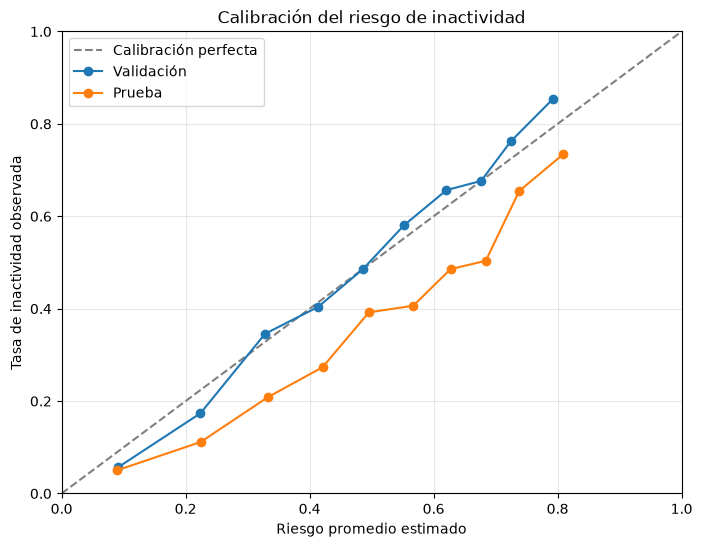

In [25]:
validation_actual_rate, validation_predicted_risk = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile"
)

test_actual_rate, test_predicted_risk = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="quantile"
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Calibración perfecta"
)

ax.plot(
    validation_predicted_risk,
    validation_actual_rate,
    marker="o",
    label="Validación"
)

ax.plot(
    test_predicted_risk,
    test_actual_rate,
    marker="o",
    label="Prueba"
)

ax.set_title("Calibración del riesgo de inactividad")
ax.set_xlabel("Riesgo promedio estimado")
ax.set_ylabel("Tasa de inactividad observada")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.show()

La calibración fue adecuada durante la validación, pero el modelo sobreestimó el nivel general de inactividad en el período de prueba. La diferencia coincide con una reducción temporal de la tasa de inactividad.

El resultado conserva capacidad para ordenar y priorizar clientes, aunque sus valores no deben interpretarse como probabilidades exactas fuera del período de entrenamiento. Por este motivo, la salida se presentará como un score de riesgo y requerirá seguimiento y recalibración con datos recientes.

In [26]:
from sklearn.inspection import permutation_importance


permutation_results = permutation_importance(
    logistic_model,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_summary = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance_mean": permutation_results.importances_mean,
        "importance_std": permutation_results.importances_std
    }
)

permutation_summary = permutation_summary.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

display(permutation_summary.round(4))

,feature,importance_mean,importance_std
0,order_count,0.2360,0.0098
1,tenure_days,0.0335,0.0049
2,orders_last_90d,0.0261,0.0066
3,average_order_value,0.0117,0.0040
4,spend_last_90d,0.0100,0.0030
5,unique_products_last_90d,0.0087,0.0037
6,total_spend,0.0009,0.0009
7,recency_days,0.0008,0.0008
8,unique_products,-0.0001,0.0001
9,orders_last_30d,-0.0004,0.0013


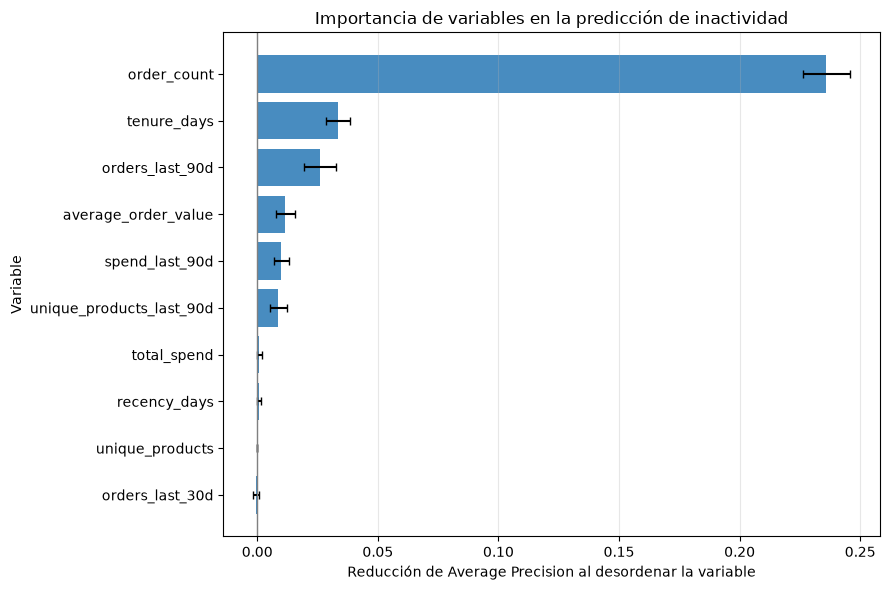

In [27]:
importance_plot_data = permutation_summary.sort_values(
    "importance_mean",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    importance_plot_data["feature"],
    importance_plot_data["importance_mean"],
    xerr=importance_plot_data["importance_std"],
    color="#2878B5",
    alpha=0.85,
    capsize=3
)

ax.axvline(0, color="gray", linewidth=1)

ax.set_title("Importancia de variables en la predicción de inactividad")
ax.set_xlabel("Reducción de Average Precision al desordenar la variable")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Conclusiones del modelado

La regresión logística superó al baseline y al modelo basado únicamente en recencia. En el período de prueba alcanzó un ROC AUC de 0.759 y detectó el 84.1% de los clientes inactivos.

La priorización también mostró valor operativo. El 30% de clientes con mayor score concentró el 49.5% de los casos de inactividad, mientras que el nivel crítico reunió el 50.9% de los casos revisando el 31.2% de la cartera.

La cantidad histórica de pedidos fue la señal predictiva más importante. La antigüedad del cliente y su actividad durante los últimos 90 días aportaron información adicional.

El cambio temporal de la tasa de inactividad produjo una sobreestimación del riesgo en el período de prueba. La salida se utilizará como score de priorización y deberá monitorearse y recalibrarse cuando se incorporen datos más recientes.